**Figure 3: Distance decay of epistasis signal across model architectures.** **(a)** Mean normalized epistasis residual ($R_\text{singles}$) as a function of genomic distance between variant pairs, computed in log-spaced bins across all available sources (>100,000 pairs per model). Track-based models (terracotta: Borzoi, AlphaGenome) maintain substantial signal beyond 1 kb, while embedding models (blue) show rapid decay. **(b)** Tail/peak ratio (mean $R_\text{singles}$ at >1 kb / max $R_\text{singles}$ at <1 kb) for each model, quantifying long-range signal retention. Track-based models approach 1.0, consistent with their training on functional genomic tracks that integrate information across long genomic windows. This distance dependence motivates the distance-controlled statistical testing used throughout subsequent analyses.

**Supplementary panels** (below): Single-mutation embedding perturbation by source (z-scored to 1kGP), single-mutation effect vs pair distance, and within-pair asymmetry comparing eQTL pairs to LD-correlated controls.

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pyarrow.dataset as ds

# ── Configuration via paper_data_config ──
sys.path.insert(0, str(Path("..").resolve()))
from paper_data_config import EPISTASIS_PAPER_ROOT

PARQUET_DIR = EPISTASIS_PAPER_ROOT / "combined_parquets" / "parquets_epi"
OUT_DIR = EPISTASIS_PAPER_ROOT / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Style (matches other figures) ──
GRAY_LIGHT, GRAY_MID, GRAY_DARK = "#E8E8E8", "#999999", "#333333"
COL_BLUE, COL_TERRA = "#4A7FB5", "#CB6A49"
mm = 1 / 25.4

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
    "font.size": 7, "axes.linewidth": 0.4, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6.5,
    "xtick.major.size": 2, "ytick.major.size": 2,
    "xtick.major.width": 0.4, "ytick.major.width": 0.4,
    "xtick.major.pad": 2, "ytick.major.pad": 2,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.unicode_minus": False,
})

MODELS = {
    "alphagenome": "AlphaGenome", "borzoi": "Borzoi", "caduceus": "Caduceus",
    "convnova": "ConvNova", "dnabert": "DNABERT", "evo2": "Evo2",
    "hyenadna": "HyenaDNA", "mutbert": "MutBERT",
    "nt50_3mer": "NT-50M-3mer", "nt50_multi": "NT-50M",
    "nt100_multi": "NT-100M", "nt250_multi": "NT-250M",
    "nt500_multi": "NT-500M", "nt500_ref": "NT-500M-ref",
    "nt2500_multi": "NT-2.5B", "nt2500_okgp": "NT-2.5B-1kGP",
    "rinalmo": "RiNALMo", "specieslm": "SpeciesLM",
}
TRACK_MODELS = {"alphagenome", "borzoi"}

def setup_ax(ax):
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_linewidth(0.4)
        ax.spines[sp].set_color(GRAY_MID)
    ax.tick_params(colors=GRAY_DARK, which="both")

def panel_label(ax, letter, x=-0.12):
    ax.text(x, 1.03, letter, transform=ax.transAxes, fontsize=9,
            fontweight="bold", va="bottom", ha="right", color="black")

def parse_dist(eid):
    parts = eid.split("|")
    return abs(int(parts[1].split(":")[2]) - int(parts[0].split(":")[2]))

print("Setup OK")

In [26]:
# ═══════════════════════════════════════════════════════════════════════
# Compute distance decay curves — pool all sources per model
# ═══════════════════════════════════════════════════════════════════════

SOURCES = ["fas_exon", "kras_neighborhood", "okgp_chr12",
           "mst1r_splicing", "correlated_eqtl", "yang_evqtl",
           "gtex_matched_null", "gtex_independent"]

curves = {}
for key, display in MODELS.items():
    fp = PARQUET_DIR / f"epistasis_metrics_{key}_combined.parquet"
    if not fp.exists():
        continue
    print(f"  {display}...", end=" ", flush=True)

    dset = ds.dataset(fp)
    tbl = dset.to_table(
        columns=["source", "epistasis_id", "epi_R_singles"],
        filter=ds.field("source").isin(SOURCES),
    )
    df = tbl.to_pandas(); del tbl
    df = df.drop_duplicates(subset=["source", "epistasis_id"])
    df["distance"] = df["epistasis_id"].apply(parse_dist)
    df = df.dropna(subset=["epi_R_singles", "distance"])
    df = df[df.distance > 0]

    # Log-spaced bins
    max_d = max(df.distance.max(), 100)
    bins = np.logspace(0, np.log10(max_d + 1), 25)
    df["dbin"] = pd.cut(df.distance, bins=bins)
    curve = df.groupby("dbin", observed=True).agg(
        mean_r=("epi_R_singles", "mean"),
        n=("epi_R_singles", "count"),
    )
    curve = curve[curve.n >= 10]
    centers = np.array([(b.left + b.right) / 2 for b in curve.index])
    values = curve["mean_r"].values

    curves[display] = (centers, values)
    del df
    print(f"done ({len(centers)} bins)")

print(f"\n{len(curves)} models with decay curves")

  AlphaGenome... done (22 bins)
  Borzoi... done (22 bins)
  Caduceus... done (22 bins)
  ConvNova... done (22 bins)
  DNABERT... done (22 bins)
  Evo2... done (22 bins)
  HyenaDNA... done (22 bins)
  MutBERT... done (22 bins)
  NT-50M-3mer... done (22 bins)
  NT-50M... done (22 bins)
  NT-100M... done (22 bins)
  NT-250M... done (22 bins)
  NT-500M... done (22 bins)
  NT-500M-ref... done (22 bins)
  NT-2.5B... done (22 bins)
  NT-2.5B-1kGP... done (22 bins)
  RiNALMo... done (22 bins)
  SpeciesLM... done (22 bins)

18 models with decay curves


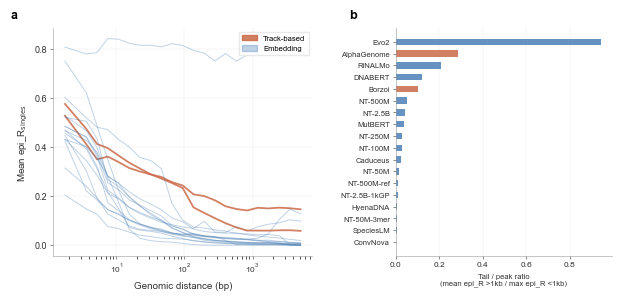

Saved fig_distance_decay to /Users/nicolaslynn/Downloads/output_figs


In [27]:
# ═══════════════════════════════════════════════════════════════════════
# Figure: Distance decay — (a) curves, (b) tail/peak ratio
# ═══════════════════════════════════════════════════════════════════════

# Compute tail/peak ratios
ratios = {}
for model, (centers, values) in curves.items():
    if len(values) < 5:
        continue
    peak = np.max(values[:8])  # short-range peak
    tail_mask = centers > 1000
    tail = np.mean(values[tail_mask]) if tail_mask.sum() > 0 else 0
    ratios[model] = tail / peak if peak > 0 else 0

sorted_models = sorted(ratios.keys(), key=lambda m: ratios[m], reverse=True)

# Map display names back to keys for track/embed coloring
display_to_key = {v: k for k, v in MODELS.items()}

fig, (ax_d, ax_r) = plt.subplots(
    1, 2, figsize=(183 * mm, 75 * mm),
    gridspec_kw={"wspace": 0.35, "width_ratios": [1.2, 1]},
)
for ax in (ax_d, ax_r):
    setup_ax(ax)

# ── Panel A: decay curves ──
for model in sorted_models:
    centers, values = curves[model]
    key = display_to_key.get(model, "")
    is_track = key in TRACK_MODELS
    color = COL_TERRA if is_track else COL_BLUE
    alpha = 0.85 if is_track else 0.35
    lw = 1.3 if is_track else 0.7
    ax_d.plot(centers, values, color=color, linewidth=lw, alpha=alpha, label=model if is_track else None)

ax_d.set_xscale("log")
ax_d.set_xlabel("Genomic distance (bp)", fontsize=7, color=GRAY_DARK)
ax_d.set_ylabel(r"Mean epi_R$_{\mathrm{singles}}$", fontsize=7, color=GRAY_DARK)
ax_d.xaxis.grid(True, color=GRAY_LIGHT, linewidth=0.3, zorder=0)
ax_d.yaxis.grid(True, color=GRAY_LIGHT, linewidth=0.3, zorder=0)
ax_d.set_axisbelow(True)

track_patch = mpatches.Patch(color=COL_TERRA, alpha=0.85, label="Track-based")
embed_patch = mpatches.Patch(color=COL_BLUE, alpha=0.35, label="Embedding")
ax_d.legend(handles=[track_patch, embed_patch], fontsize=5.5, frameon=True,
            fancybox=False, edgecolor=GRAY_LIGHT, loc="upper right", framealpha=0.95)
panel_label(ax_d, "a", x=-0.14)

# ── Panel B: tail/peak ratio bars ──
n_r = len(sorted_models)
y_r = np.arange(n_r)
bar_vals = [ratios[m] for m in sorted_models]
bar_cols = [COL_TERRA if display_to_key.get(m, "") in TRACK_MODELS else COL_BLUE for m in sorted_models]

ax_r.barh(y_r, bar_vals, height=0.55, color=bar_cols, edgecolor="none", alpha=0.85, zorder=2)
ax_r.xaxis.grid(True, color=GRAY_LIGHT, linewidth=0.3, zorder=0)
ax_r.set_axisbelow(True)
ax_r.set_xlabel("Tail / peak ratio\n(mean epi_R >1kb / max epi_R <1kb)", fontsize=5.5, color=GRAY_DARK)
ax_r.set_yticks(y_r)
ax_r.set_yticklabels(sorted_models, fontsize=5.5)
ax_r.invert_yaxis()
panel_label(ax_r, "b", x=-0.18)

for ext in (".png", ".pdf"):
    fig.savefig(OUT_DIR / f"fig_distance_decay{ext}", dpi=600,
                bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print(f"Saved fig_distance_decay to {OUT_DIR}")





## Single-mutation embedding effects

Three analyses using `len_WT_M1` / `len_WT_M2` (how far each mutation moves the embedding from wild type):

1. **Effect size by source** — do functional variants (eQTL, FAS, KRAS) perturb embeddings more than 1kGP background? (z-scored per model)
2. **Single-mutation effect vs genomic distance** — does `len_WT` depend on distance between the two variants? (It shouldn't for embedding models, but track models share context windows.)
3. **Asymmetry** — how unequal are the two mutations in each pair? Functional pairs might have one dominant causal variant.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Load per-source single-mutation data from new_embeddings
# ═══════════════════════════════════════════════════════════════════════

NEW_DIR = EPISTASIS_PAPER_ROOT / "combined_parquets" / "new_embeddings"
COMPARE_SOURCES = ["fas_exon", "kras_neighborhood", "yang_evqtl", "okgp_chr12", "correlated_eqtl"]
SRC_LABELS = {
    "fas_exon": "FAS exon", "kras_neighborhood": "KRAS", "yang_evqtl": "eQTL",
    "okgp_chr12": "1kGP chr12", "correlated_eqtl": "topLD control",
}
SRC_COLORS = {"FAS exon": "#4A7FB5", "KRAS": "#CB6A49", "eQTL": "#5BA05B",
              "1kGP chr12": "#D4A843", "topLD control": "#8BB8DB"}

single_mut_data = []

for key, display in MODELS.items():
    fp = NEW_DIR / f"epistasis_metrics_{key}_combined.parquet"
    if not fp.exists():
        fp = PARQUET_DIR / f"epistasis_metrics_{key}_combined.parquet"
    if not fp.exists():
        continue
    print(f"  {display}...", end=" ", flush=True)

    dset = ds.dataset(fp)
    tbl = dset.to_table(
        columns=["source", "epistasis_id", "len_WT_M1", "len_WT_M2"],
        filter=ds.field("source").isin(COMPARE_SOURCES),
    )
    df = tbl.to_pandas(); del tbl
    df = df.drop_duplicates(subset=["source", "epistasis_id"])
    df = df.dropna(subset=["len_WT_M1", "len_WT_M2"])

    # Subsample 1kGP for memory
    okgp_mask = df.source == "okgp_chr12"
    if okgp_mask.sum() > 20000:
        df = pd.concat([df[~okgp_mask], df[okgp_mask].sample(20000, random_state=42)])

    df["max_wt"] = np.maximum(df["len_WT_M1"], df["len_WT_M2"])
    df["asym"] = np.abs(df["len_WT_M1"] - df["len_WT_M2"]) / (df["len_WT_M1"] + df["len_WT_M2"] + 1e-30)
    df["distance"] = df["epistasis_id"].apply(parse_dist)

    # Z-score max_wt using 1kGP as reference
    bg = df.loc[df.source == "okgp_chr12", "max_wt"]
    bg_mean, bg_std = bg.mean(), bg.std()
    if bg_std < 1e-12:
        print("skip (zero var)")
        continue
    df["max_wt_z"] = (df["max_wt"] - bg_mean) / bg_std

    for _, row in df.iterrows():
        single_mut_data.append({
            "model": display, "model_key": key,
            "source": SRC_LABELS.get(row["source"], row["source"]),
            "max_wt_z": row["max_wt_z"],
            "max_wt": row["max_wt"],
            "asym": row["asym"],
            "distance": row["distance"],
        })
    del df
    print("done")

SM = pd.DataFrame(single_mut_data)
print(f"\n{len(SM):,} rows across {SM.model.nunique()} models")

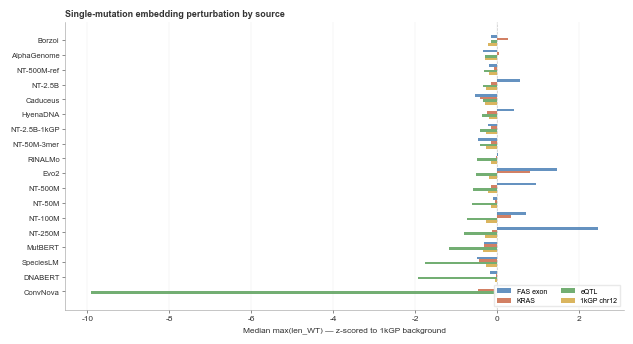

Saved fig_single_mut_effect to /Users/nicolaslynn/Downloads/output_figs


In [29]:
# ═══════════════════════════════════════════════════════════════════════
# Plot 1: Single-mutation effect size by source (z-scored to 1kGP)
# Median max(len_WT) per model×source, bar chart
# ═══════════════════════════════════════════════════════════════════════

# Aggregate: median z-scored max_wt per model × source
agg = SM.groupby(["model", "source"])["max_wt_z"].median().reset_index()
agg = agg.rename(columns={"max_wt_z": "median_z"})

# Sort models by eQTL median_z
eqtl_order = agg[agg.source == "eQTL"].sort_values("median_z", ascending=False)
model_order = eqtl_order["model"].tolist()
# Add any models missing eQTL
for m in SM.model.unique():
    if m not in model_order:
        model_order.append(m)

n_m = len(model_order)
src_list = ["FAS exon", "KRAS", "eQTL", "1kGP chr12"]
n_src = len(src_list)
bar_w = 0.18
offsets = (np.arange(n_src) - (n_src - 1) / 2) * bar_w

fig1, ax1 = plt.subplots(figsize=(183 * mm, max(70, 4.5 * n_m + 14) * mm))
setup_ax(ax1)

y_pos = np.arange(n_m)
for j, src in enumerate(src_list):
    vals = []
    for m in model_order:
        row = agg[(agg.model == m) & (agg.source == src)]
        vals.append(row["median_z"].values[0] if len(row) else 0)
    ax1.barh(y_pos + offsets[j], vals, height=bar_w, color=SRC_COLORS[src],
             edgecolor="none", alpha=0.85, zorder=2, label=src)

ax1.axvline(0, color=GRAY_MID, linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(model_order, fontsize=5.5)
ax1.invert_yaxis()
ax1.set_xlabel("Median max(len_WT) — z-scored to 1kGP background", fontsize=6, color=GRAY_DARK)
ax1.xaxis.grid(True, color=GRAY_LIGHT, linewidth=0.3, zorder=0)
ax1.set_axisbelow(True)
ax1.legend(fontsize=5, loc="lower right", frameon=True, fancybox=False,
           edgecolor=GRAY_LIGHT, framealpha=0.95, borderpad=0.4, ncol=2)
ax1.set_title("Single-mutation embedding perturbation by source",
              fontsize=6.5, color=GRAY_DARK, pad=4, loc="left", fontweight="bold")

for ext in (".png", ".pdf"):
    fig1.savefig(OUT_DIR / f"fig_single_mut_effect{ext}", dpi=600,
                 bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print(f"Saved fig_single_mut_effect to {OUT_DIR}")

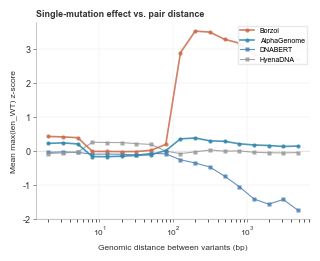

Saved fig_single_mut_vs_distance to /Users/nicolaslynn/Downloads/output_figs


In [30]:
# ═══════════════════════════════════════════════════════════════════════
# Plot 2: Single-mutation WT distance vs genomic distance
# Does len_WT depend on how far apart the two variants are?
# Track models: yes (shared context window). Embedding models: no.
# ═══════════════════════════════════════════════════════════════════════

# Use 4 representative models
show_models = ["Borzoi", "AlphaGenome", "DNABERT", "HyenaDNA"]
show_colors = {"Borzoi": COL_TERRA, "AlphaGenome": "#2E86AB", "DNABERT": COL_BLUE, "HyenaDNA": GRAY_MID}

fig2, ax2 = plt.subplots(figsize=(90 * mm, 65 * mm))
setup_ax(ax2)

for model in show_models:
    sub = SM[(SM.model == model) & (SM.distance > 0)].copy()
    if len(sub) == 0:
        continue
    # Bin by distance (log-spaced)
    max_d = sub.distance.max()
    bins = np.logspace(0, np.log10(max_d + 1), 20)
    sub["dbin"] = pd.cut(sub.distance, bins=bins)
    binned = sub.groupby("dbin", observed=True).agg(
        mean_wt=("max_wt_z", "mean"),
        n=("max_wt_z", "count"),
    )
    binned = binned[binned.n >= 10]
    centers = np.array([(b.left + b.right) / 2 for b in binned.index])

    is_track = model in ["Borzoi", "AlphaGenome"]
    ax2.plot(centers, binned["mean_wt"].values,
             color=show_colors[model], linewidth=1.2 if is_track else 0.8,
             marker="o" if is_track else "s", markersize=3, markeredgecolor="none",
             alpha=0.85, label=model, zorder=4 if is_track else 3)

ax2.set_xscale("log")
ax2.axhline(0, color=GRAY_MID, linewidth=0.4, linestyle="--", alpha=0.5)
ax2.set_xlabel("Genomic distance between variants (bp)", fontsize=6, color=GRAY_DARK)
ax2.set_ylabel("Mean max(len_WT) z-score", fontsize=6, color=GRAY_DARK)
ax2.xaxis.grid(True, color=GRAY_LIGHT, linewidth=0.3, zorder=0)
ax2.yaxis.grid(True, color=GRAY_LIGHT, linewidth=0.3, zorder=0)
ax2.set_axisbelow(True)
ax2.legend(fontsize=5, loc="upper right", frameon=True, fancybox=False,
           edgecolor=GRAY_LIGHT, framealpha=0.95, borderpad=0.3)
ax2.set_title("Single-mutation effect vs. pair distance",
              fontsize=6.5, color=GRAY_DARK, pad=4, loc="left", fontweight="bold")

for ext in (".png", ".pdf"):
    fig2.savefig(OUT_DIR / f"fig_single_mut_vs_distance{ext}", dpi=600,
                 bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print(f"Saved fig_single_mut_vs_distance to {OUT_DIR}")


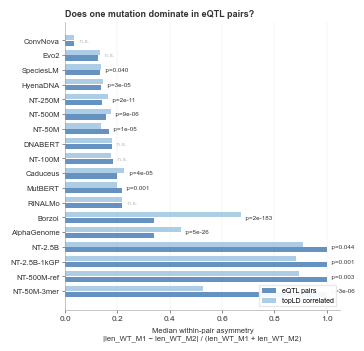

Saved fig_single_mut_asymmetry to /Users/nicolaslynn/Downloads/output_figs


In [32]:
# ═══════════════════════════════════════════════════════════════════════
# Plot 3: Within-pair asymmetry — eQTL vs topLD correlated
# For each pair: |len_WT_M1 - len_WT_M2| / (len_WT_M1 + len_WT_M2)
# If models recognize the causal eQTL variant, eQTL pairs should be
# more asymmetric (one mutation clearly dominates).
# ═══════════════════════════════════════════════════════════════════════
from scipy.stats import mannwhitneyu

asym_rows = []
for model in SM.model.unique():
    eqtl = SM[(SM.model == model) & (SM.source == "eQTL")]["asym"].values
    ctrl = SM[(SM.model == model) & (SM.source == "topLD control")]["asym"].values
    if len(eqtl) < 20 or len(ctrl) < 20:
        continue
    _, p = mannwhitneyu(eqtl, ctrl, alternative="two-sided")
    asym_rows.append({
        "model": model,
        "eqtl_median": np.median(eqtl),
        "ctrl_median": np.median(ctrl),
        "mwu_p": float(p),
    })

asym_stats = pd.DataFrame(asym_rows)
asym_stats = asym_stats.sort_values("eqtl_median", ascending=True).reset_index(drop=True)
n_a = len(asym_stats)

fig3, ax3 = plt.subplots(figsize=(90 * mm, max(65, 4.5 * n_a + 14) * mm))
setup_ax(ax3)

y = np.arange(n_a)
bar_h = 0.35

ax3.barh(y + bar_h/2 + 0.02, asym_stats["eqtl_median"].values,
         height=bar_h, color=COL_BLUE, edgecolor="none", alpha=0.85, zorder=2,
         label="eQTL pairs")
ax3.barh(y - bar_h/2 - 0.02, asym_stats["ctrl_median"].values,
         height=bar_h, color="#8BB8DB", edgecolor="none", alpha=0.7, zorder=2,
         label="topLD correlated")

# P-value annotations
for i in range(n_a):
    p = asym_stats.iloc[i]["mwu_p"]
    eqtl_v = asym_stats.iloc[i]["eqtl_median"]
    ctrl_v = asym_stats.iloc[i]["ctrl_median"]
    x_right = max(eqtl_v, ctrl_v)
    if p < 0.001:
        p_str = f"p={p:.0e}"
    elif p < 0.05:
        p_str = f"p={p:.3f}"
    else:
        p_str = "n.s."
    col = GRAY_DARK if p < 0.05 else "#BBBBBB"
    ax3.text(x_right + 0.005, y[i], f"  {p_str}",
             ha="left", va="center", fontsize=4.5, color=col)

ax3.set_yticks(y)
ax3.set_yticklabels(asym_stats["model"].tolist(), fontsize=5.5)
ax3.invert_yaxis()
ax3.set_xlabel("Median within-pair asymmetry\n|len_WT_M1 \u2212 len_WT_M2| / (len_WT_M1 + len_WT_M2)",
               fontsize=5.5, color=GRAY_DARK)
ax3.xaxis.grid(True, color=GRAY_LIGHT, linewidth=0.3, zorder=0)
ax3.set_axisbelow(True)
ax3.legend(fontsize=5, loc="lower right", frameon=True, fancybox=False,
           edgecolor=GRAY_LIGHT, framealpha=0.95, borderpad=0.4)
ax3.set_title("Does one mutation dominate in eQTL pairs?",
              fontsize=6.5, color=GRAY_DARK, pad=4, loc="left", fontweight="bold")

for ext in (".png", ".pdf"):
    fig3.savefig(OUT_DIR / f"fig_single_mut_asymmetry{ext}", dpi=600,
                 bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print(f"Saved fig_single_mut_asymmetry to {OUT_DIR}")

